In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [ ]:
# URLs de datos de Airbnb
url_listings = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2026-06-20/visualisations/listings.csv"
url_listings_det = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2026-06-20/data/listings.csv.gz"

# Importar datasets
listings = pd.read_csv(url_listings)
listings_det = pd.read_csv(url_listings_det)

In [41]:
print(f"listings: {listings.shape}")
print(f"listings_det: {listings_det.shape}")
listings.head(1)

listings: (18961, 10)
listings_det: (22708, 13)


,id,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,availability_365
0,1008521039996399925,Alojamiento tranquilo,Carabanchel,Opañel,40.38799,-3.7247,Private room,42.0,1.0,268


In [28]:
listings_det.head(1)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1008521039996399925,https://www.airbnb.com/rooms/1008521039996399925,20260620164952,2026-06-20,city scrape,Alojamiento tranquilo,You'll be in a family and quiet atmosphere.,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,509530871,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN


In [4]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 22835 entries, 0 to 22834
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              22835 non-null  int64  
 1   name                            22835 non-null  str    
 2   host_id                         22708 non-null  float64
 3   host_profile_id                 22556 non-null  float64
 4   host_name                       22556 non-null  str    
 5   neighbourhood_group             22835 non-null  str    
 6   neighbourhood                   22835 non-null  str    
 7   latitude                        22835 non-null  float64
 8   longitude                       22835 non-null  float64
 9   room_type                       22835 non-null  str    
 10  price                           19297 non-null  float64
 11  minimum_nights                  22833 non-null  float64
 12  number_of_reviews               22835 non-n

In [29]:
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 22708 entries, 0 to 22707
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22708 non-null  int64  
 1   listing_url                                   22708 non-null  str    
 2   scrape_id                                     22708 non-null  int64  
 3   last_scraped                                  22708 non-null  str    
 4   source                                        22708 non-null  str    
 5   name                                          22708 non-null  str    
 6   description                                   21823 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   22707 non-null  str    
 9   host_id                                       22708 non-null  int64  
 1

## Análisis previo (objetivos y variables)

Necesitamos obtener una base amplia de inmuebles de referencia con alto rendimiento que nos sirvan como guia para la futura compra de inmuebles. Para evaluar el **rendimiento de dichos inmbuebles**, necesitamos conocer:

* **Beneficio anual esperado**: lo obtendremos mediante la ocupacion anual estimada (necesitamos inmuebles con elevada ocupacion) y el precio por noche. No nos sirven inmuebles muy recientes ya que no podemos evaluar su historicos de ocupación, por lo tanto el corte será de al menos **10 meses de antiguedad** del anuncio.

* **Precio/Coste del inmueble**: esto lo obtendremos posteriormente gracias a datos de precio m2 de idealista y a un proxy para obtener m2 aproximados de las viviendas.
Necesitamos determinar por un lado **la antiguedad de anuncio** de los inmuebles para poder obtener datos de ocupación fiables, por otro lado necesitamos calcular **el margen bruto anual esperado**, el cual obtendremos dvidiendo el revenue anual esperado / coste adqusicion del inmueble entre los años de amortización y también la **ocupación estimada de los inmuebles** para descartar inmuebles con bajo rendimiento. Por ahora las metricas que nos ofrecen puntos de partida son:

* Variables útiles del dataset:

1. **first_review** de *listings_det* nos indica fecha de la primera review del inmueble. Es la metrica mas fiable que tenemos para saber la antiguedad del inmueble.

2. **estimated_occupancy_l365d** de *listings_det* nos indica la cantidad de dias que se espera que ese inmueble sea alquilado en el proximo año. Los valores 0 son debido a inmuebles nuevos que no tienen historial para generar este dato. Nos interesan inmuebles que tengan una **ocupación estimada media-alta** ya que buscamos insights de inmuebles con alto rendimiento actual.

3. **price** de *listings* nos indica el precio por noche del inmueble.

4. **estimated_revenue_l365d**: se analizará la variable para evaluar si es mejor usarla o generar una nueva variable de revenue anual esperado.


**Conclusión**: Se excluirán del análisis inmuebles que tengan anuncios con menos de un año de antiguedad y inmuebles con baja ocupación. Esto reducirá el tamaño del dataset pero aumentara significativamente la calidad de los datos y ayudara a su correcta interpretación y análisis posteriores.

In [5]:
# Eliminar variables que no nos aportan valor.
# No vamos a eliminar la variable id ya que vincula ambos datasets
a_eliminar= ['host_id','host_profile_id', 'host_name','number_of_reviews', 'last_review',
       'reviews_per_month','calculated_host_listings_count','number_of_reviews_ltm', 'license']

listings = listings.drop(columns= a_eliminar)

In [6]:
#analisis de nulos
listings.isnull().sum()

id                        0
name                      0
neighbourhood_group       0
neighbourhood             0
latitude                  0
longitude                 0
room_type                 0
price                  3538
minimum_nights            2
availability_365          0
dtype: int64

In [7]:
#Eliminar registros que contienen nulos debido a que no son muchos y no queremos imputar datos debido a la naturaleza del proyecto
listings = listings.dropna()

In [9]:
#revisar si existen duplicados
listings.duplicated().sum()

np.int64(0)

In [10]:
# Analisis previo de variables categoricas(value counts de variables tipo string)
str_cols = listings.select_dtypes(include='str').columns

for col in str_cols:
    print(f"\n{'='*60}")
    print(f"Variable: {col}")
    print(f"{'='*60}")
    print(listings[col].value_counts())


Variable: name
name
Habitación en piso compartido                       154
Housing Castellana by Sharing Co                     39
Great Studio                                         20
Fantastic residence ``FUNWAY´´ north zone Madrid     18
Habitación piso compartido                           15
                                                   ... 
GuestReady - Modern Studio near Downtown              1
Studio with balcony                                   1
Two bedroom apartment with view                       1
One bedroom superior apartment                        1
Superior Studio                                       1
Name: count, Length: 18008, dtype: int64

Variable: neighbourhood_group
neighbourhood_group
Centro                   8213
Tetuán                   1415
Salamanca                1334
Chamberí                 1261
Arganzuela                926
Retiro                    688
Chamartín                 677
Ciudad Lineal             637
Carabanchel               609
P

In [11]:
#eliminar registros donde roomtype es "Hotel room" ya que no es el tipo de alojamiento que queremos analizar
listings = listings[listings['room_type'] != 'Hotel room'].copy()

In [12]:
#Analisis previo de variables numericas
listings[listings.select_dtypes(include=['float64', 'int64']).columns].describe().T

,count,mean,std,min,25%,50%,75%,max
id,19267.0,9.345045e+17,5.936859e+17,21853.00000,5.754865e+17,1.105589e+18,1.427381e+18,1.711741e+18
latitude,19267.0,4.042288e+01,2.360214e-02,40.33189,4.041038e+01,4.042087e+01,4.043305e+01,4.053553e+01
longitude,19267.0,-3.693770e+00,2.752559e-02,-3.82997,-3.707330e+00,-3.700950e+00,-3.685712e+00,-3.545904e+00
price,19267.0,1.802184e+02,5.542936e+02,3.00000,8.400000e+01,1.250000e+02,1.840000e+02,3.688300e+04
minimum_nights,19267.0,6.812737e+00,1.429257e+01,1.00000,1.000000e+00,2.000000e+00,4.000000e+00,3.650000e+02
availability_365,19267.0,2.225902e+02,1.106256e+02,0.00000,1.250000e+02,2.470000e+02,3.240000e+02,3.650000e+02


* Hay que hacer una inspeccion mas detallada de **price** para determinar que valores extremos tenemos y si es necesario eliminarlos o no.
* La media de **minimum_nights** nos saca un valor poco realista. En cambio, la mediana al 50% y 75% no dice que se suelen alquilar entre 2-4 noches.
* Sobre **availability_365** nada a destacar, ya que solo contabiliza la cantidad de dias que el alojamiento estuvo disponible para alquilar.

## Precio por noche

Registros con precio < 50: 1935 de 19267


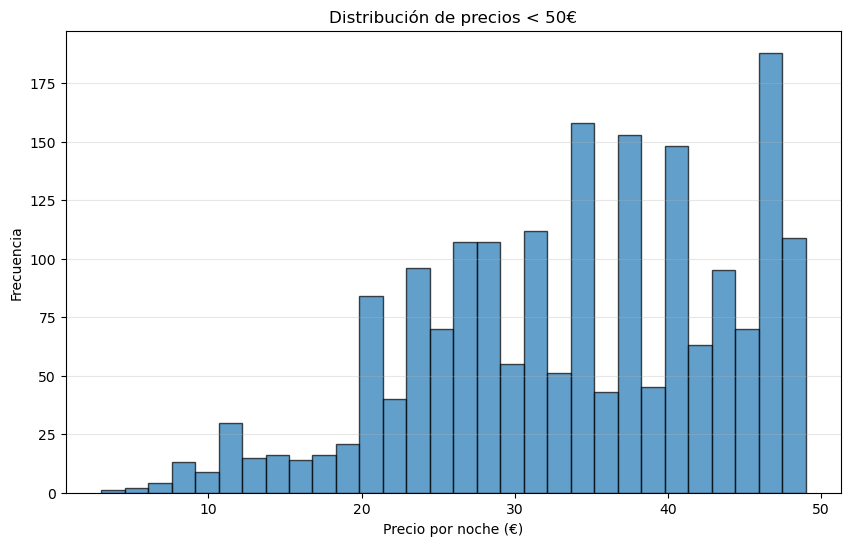

In [13]:
# Filtrar registros con precio < 50
listings_precio_bajo = listings[listings['price'] < 50]

print(f"Registros con precio < 50: {len(listings_precio_bajo)} de {len(listings)}")

# Generar histograma
plt.figure(figsize=(10, 6))
plt.hist(listings_precio_bajo['price'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Precio por noche (€)')
plt.ylabel('Frecuencia')
plt.title('Distribución de precios < 50€')
plt.grid(axis='y', alpha=0.3)
plt.show()

20€ seria un buen punto de corte porque a partir de ese punto la frecuencia de precios es muy baja y se podrían considerar como valores atípicos. Sin embargo, esta decisión también dependerá del contexto del análisis y de los objetivos del proyecto.

Registros con precio > 1000: 165 de 19267


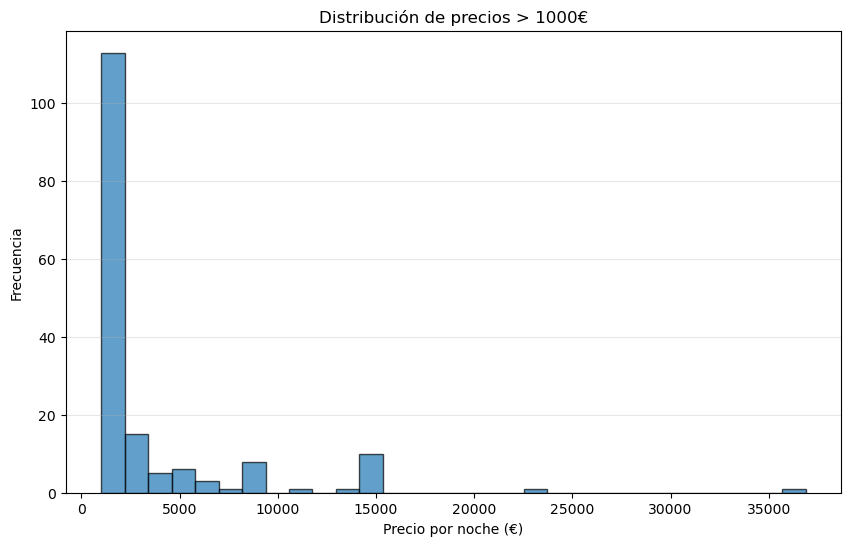

In [14]:
# Filtrar registros con precio > 300
listings_precio_alto = listings[listings['price'] > 1000]

print(f"Registros con precio > 1000: {len(listings_precio_alto)} de {len(listings)}")

# Generar histograma
plt.figure(figsize=(10, 6))
plt.hist(listings_precio_alto['price'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Precio por noche (€)')
plt.ylabel('Frecuencia')
plt.title('Distribución de precios > 1000€')
plt.grid(axis='y', alpha=0.3)
plt.show()

Para este caso, lo logico seria sentarse con el encargado de negocio y hacer este ejercicio de forma intercativa para determinar los puntos de corte mas adecuados.
* En este caso, se han elegido 20€ y 1000€ como puntos de corte para eliminar los valores atípicos en la variable "price".

In [15]:
#qudarnos con registros entre 20 y 1000 euros noche
listings = listings[(listings['price'] >= 20) & (listings['price'] <= 1000)]

listings.price.describe().T

count    18961.000000
mean       152.891514
std        116.186700
min         20.000000
25%         85.000000
50%        125.000000
75%        183.000000
max       1000.000000
Name: price, dtype: float64

#### Dataset de listings detallado

In [30]:
#Eliminamos Hotel room ya que es un tipo de inmueble que no queremos como referencia ya que no es el tipo de alojamiento buscado
listings_det = listings_det.loc[listings_det['room_type'] != 'Hotel room'].copy()

In [31]:
#variables a incluir en el dataset final
a_incluir = ['id',
             'description',
             'first_review',
             'room_type',
             'accommodates',
             'bathrooms',
             'bedrooms',
             'beds',
             'estimated_occupancy_l365d',
             'estimated_revenue_l365d',
             'neighbourhood_group_cleansed',
             'review_scores_location']

listings_det = listings_det[a_incluir]

## Antiguedad del anuncio

In [32]:
#variable temporal de corte actualizada a datetime
cutoff_date = pd.Timestamp("2025-08-20")
listings_det["first_review"] = pd.to_datetime(listings_det["first_review"])

In [33]:
print(listings_det.shape)
print(listings_det[listings_det["first_review"].notna() & (listings_det["first_review"] <= cutoff_date)].shape)

(22669, 12)
(15415, 12)


Descartamos anuncios con menos de 1 año de antiguedad

In [34]:
#dataset filtrado por el cutoff
listings_det = listings_det[listings_det["first_review"].notna() & (listings_det["first_review"] <= cutoff_date)]

## Ocupación

Comprovacion de ocupacion estimada segun room type

In [35]:
#Ocupacion estimada anual por room type
listings_det.groupby("room_type").estimated_occupancy_l365d.describe(percentiles=[0.25, 0.5, 0.55, 0.6, 0.75])

,count,mean,std,min,25%,50%,55%,60%,75%,max
room_type,,,,,,,,,,
Entire home/apt,11166.0,124.505105,98.555107,0.0,24.0,114.0,132.0,162.0,240.0,255.0
Private room,4159.0,89.198125,98.818595,0.0,0.0,48.0,62.0,84.0,180.0,255.0
Shared room,90.0,115.422222,95.521040,0.0,30.0,81.0,101.7,114.0,238.5,255.0


Comprovacion de ocupacion estimada por barrio

In [36]:
#Cantidad de listings por barrio al aplicar cutoffs por percentiles de ocupacion
print(listings_det[listings_det.estimated_occupancy_l365d.ge(listings_det.estimated_occupancy_l365d.quantile(0.25))].groupby('neighbourhood_group_cleansed').id.count())
print(listings_det[listings_det.estimated_occupancy_l365d.ge(listings_det.estimated_occupancy_l365d.quantile(0.5))].groupby('neighbourhood_group_cleansed').id.count())

neighbourhood_group_cleansed
Arganzuela                635
Barajas                    77
Carabanchel               381
Centro                   5468
Chamartín                 375
Chamberí                  632
Ciudad Lineal             386
Fuencarral - El Pardo     138
Hortaleza                 232
Latina                    235
Moncloa - Aravaca         263
Moratalaz                  53
Puente de Vallecas        336
Retiro                    409
Salamanca                 712
San Blas - Canillejas     237
Tetuán                    755
Usera                     250
Vicálvaro                  34
Villa de Vallecas          41
Villaverde                 89
Name: id, dtype: int64
neighbourhood_group_cleansed
Arganzuela                454
Barajas                    61
Carabanchel               223
Centro                   3802
Chamartín                 217
Chamberí                  374
Ciudad Lineal             249
Fuencarral - El Pardo      74
Hortaleza                 143
Latina             

El P25 nos ofrece un corte poco optimo en cuanto a ocupación pero debido a la escasez de registros totales por barrio, **se ha decidido conservar el maximo numero de registros para asegurar los análisis posteriores.**

In [37]:
listings_det = listings_det[listings_det.estimated_occupancy_l365d.ge(listings_det.estimated_occupancy_l365d.quantile(0.25))].copy()

In [38]:
listings_det.room_type.value_counts()

room_type
Entire home/apt    9055
Private room       2603
Shared room          80
Name: count, dtype: int64

#### Estimated revenue
Se va a comprobar la variable 'estimated_revenue_l365d' para decidir si usarla como metrica final de revenue esperado.

In [39]:
precio_noche = listings[['id','price']]
estimated_revenue = listings_det[["id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]]
estimated_revenue = pd.merge(estimated_revenue, precio_noche, on="id")

In [40]:
#calculamos la variable estimated revenue manualmente
estimated_revenue['estimated_revenue_calculated'] = estimated_revenue['estimated_occupancy_l365d'] * estimated_revenue['price']

In [43]:
estimated_revenue.head(5)

,id,estimated_occupancy_l365d,estimated_revenue_l365d,price,estimated_revenue_calculated
0,1436890817650341154,72,NaN,NaN,NaN
1,1309257365923219012,36,NaN,NaN,NaN
2,710797022346365890,186,30876.0,166.0,30876.0
3,1061811091175593250,30,6680.0,223.0,6690.0
4,1383206538056423423,78,6864.0,88.0,6864.0


In [42]:
listings_det.drop(columns = ['estimated_revenue_l365d'], inplace = True)

La metrica *'estimated_revenue_l365d'* esta siendo calculada haciendo un simple producto del precio noche x la 'estimated_occupancy_l365d'. **Esto no nos sirve** ya que el precio noche no es constante para todos los tipos de inmueble. Por ejemplo, las shared rooms calculan su precio noche total en base a las rooms que tienen, por lo tanto el precio noche seria mucho mayor. Se va a calcular esta variable mas adelante en la fase de creacion de variables.

## Analisis de nulos

In [44]:
#analisis de nulos
listings_det.isnull().sum()

id                                 0
description                      347
first_review                       0
room_type                          0
accommodates                       0
bathrooms                       1431
bedrooms                        2833
beds                            1090
estimated_occupancy_l365d          0
neighbourhood_group_cleansed       0
review_scores_location             0
dtype: int64

#### Proxy para rellenar nulos usando moda o mediana segun el caso
Debido a que no podemos perder mas registros ya que la cantidad de inmuebles en algunos barrios es baja, crearemos un proxy para rellenar nulos en las variables bathrooms, bedrooms y beds. Los valores se escogerán teniendo en cuenta **la moda para cada valor de accommodates si esta es >= 50% de la proporción. En caso contrario se usará la mediana**.

In [45]:
#Agrupamos por accomodates (variable de referencia) y generamos moda, moda(%) y mediana
for col in ["bedrooms", "beds", "bathrooms"]:
    stats = listings_det.groupby("accommodates")[col].agg(
        mode=lambda x: x.mode().iloc[0],
        mode_pct=lambda x: x.value_counts(normalize=True).iloc[0],
        median="median"
    )
    # Por defecto, asignamos la mediana a los nulos
    valor = stats["median"].copy()
    #Si la moda es >= 50% usamos la moda
    valor[stats["mode_pct"] >= 0.5] = stats.loc[stats["mode_pct"] >= 0.5, "mode"]

    #Mapeamos valores al dataset original
    listings_det[col] = listings_det[col].fillna(
        listings_det["accommodates"].map(valor)
    )

In [46]:
listings_det[['bathrooms','bedrooms','beds']].isnull().sum()

bathrooms    0
bedrooms     0
beds         0
dtype: int64

### Analisis de outliers

* Visualizamos valores de todas las variables relevantes para descartar valores muy extremos. Esto deberia decidirlo el responsable del negocio pero como desconocemos esa informacion, lo haremos de forma arbitraria. El analisis se hace por room type debido a que los valores cambian considerablemente segun la naturaleza del inmueble turístico.

In [47]:
listings_det.groupby("room_type")[["beds", "bedrooms", "bathrooms"]].describe(percentiles=[0.95, 0.99]).T

room_type        Entire home/apt  Private room  Shared room
beds      count      9055.000000   2603.000000    80.000000
          mean          2.316897      1.286977     4.700000
          std           1.431598      0.984239     7.758050
          min           1.000000      1.000000     1.000000
          95%           5.000000      3.000000    20.000000
          99%           7.000000      4.000000    32.100000
          max          18.000000     19.000000    40.000000
bedrooms  count      9055.000000   2603.000000    80.000000
          mean          1.585754      1.096811     1.250000
          std           0.867978      0.633307     0.987261
          min           1.000000      1.000000     1.000000
          95%           3.000000      1.000000     3.050000
          99%           5.000000      4.000000     5.420000
          max           8.000000     18.000000     7.000000
bathrooms count      9055.000000   2603.000000    80.000000
          mean          1.303424      1.185747     1.787500
          std           0.610959      0.646917     1.771388
          min           0.500000      0.500000     1.000000
          95%           2.000000      2.000000     7.000000
          99%           3.500000      3.000000     8.000000
          max           8.000000     19.000000     8.000000

In [48]:
mask = True

for col in ["bedrooms", "beds", "bathrooms"]:

    for room_type in listings_det.room_type.unique():

        threshold = listings_det.loc[listings_det["room_type"] == room_type, col].quantile(0.99)
        room_mask = listings_det["room_type"] == room_type

        mask &= ~room_mask | (listings_det[col] <= threshold)

In [49]:
#Aplicamos mascara generada por el bucle
listings_det = listings_det.loc[mask].copy()
listings_det.shape

(11540, 11)

In [52]:
listings_det.groupby("room_type")[["beds", "bedrooms", "bathrooms"]].describe(percentiles=[0.90, 0.95]).T

room_type        Entire home/apt  Private room  Shared room
beds      count      8915.000000   2547.000000    78.000000
          mean          2.227706      1.216333     4.051282
          std           1.196892      0.552720     6.488546
          min           1.000000      1.000000     1.000000
          90%           4.000000      2.000000    12.600000
          95%           4.000000      2.000000    18.300000
          max           7.000000      4.000000    30.000000
bedrooms  count      8915.000000   2547.000000    78.000000
          mean          1.536511      1.054574     1.179487
          std           0.762515      0.307930     0.751511
          min           1.000000      1.000000     1.000000
          90%           3.000000      1.000000     1.000000
          95%           3.000000      1.000000     2.150000
          max           5.000000      4.000000     5.000000
bathrooms count      8915.000000   2547.000000    78.000000
          mean          1.265311      1.139969     1.730769
          std           0.506386      0.398274     1.727720
          min           0.500000      0.500000     1.000000
          90%           2.000000      2.000000     3.000000
          95%           2.000000      2.000000     7.000000
          max           3.500000      3.000000     8.000000

Shared room sigue presentando valores bastante anómalos de beds. Estos se filtraran manualmente

In [58]:
#Descartamos shared rooms con más de 12 camas
listings_det = listings_det.loc[~(listings_det.room_type.eq("Shared room") & listings_det.beds.ge(12))].copy()

In [59]:
listings_det.shape

(11529, 11)

In [61]:
#Seguimos con la calidad de datos de listings_det -> comprobar duplicados
listings_det.duplicated().sum()

np.int64(0)

Al eliminar outliers, pasamos de 11738 a 11529 registros (209 registros menos -> 1,7% menos).

#### Precio/m2 (datos externos de idealista de 2025)

Ahora vamos a incorporar datos externos debido a que necesitamos variables que por ahora desconocemos como el precio m2/distrito y los m2 de cada inmueble. Para obtener los m2 del inmueble se hará un proxy según caracteristicas de inmueble (haremos un proxy).

In [63]:
df_idealista = pd.read_csv("../data/raw/preciom2_madrid_2025.csv")

In [64]:
df_idealista.head(3)

,table__cell 2,icon-elbow
0,5.960 €/m2,NaN
1,6.334 €/m2,Arganzuela
2,4.901 €/m2,Barajas


In [65]:
#Renombrar columnas
df_idealista.columns = ['price_m2', 'neighbourhood_group']

#Eliminar primer registro
df_idealista = df_idealista.iloc[1:].reset_index(drop=True)

# Eliminar '€/m2' de la columna precio
df_idealista['price_m2'] = df_idealista['price_m2'].str.replace('€/m2', '').str.strip()

# Eliminar separador de miles (.) y convertir a numerico
df_idealista['price_m2'] = df_idealista['price_m2'].str.replace('.', '').astype(float)

In [66]:
distritos_i = df_idealista.neighbourhood_group.unique()
distritos_l = listings.neighbourhood_group.unique()

In [67]:
print(f"Distritos idealista: {distritos_i}")
print(f"Distritos listings: {distritos_l}")

Distritos idealista: <StringArray>
[        'Arganzuela',            'Barajas',        'Carabanchel',
             'Centro',          'Chamartín',           'Chamberí',
      'Ciudad Lineal',         'Fuencarral',          'Hortaleza',
             'Latina',            'Moncloa',          'Moratalaz',
 'Puente de Vallecas',             'Retiro',          'Salamanca',
           'San Blas',             'Tetuán',              'Usera',
          'Vicálvaro',  'Villa de Vallecas',         'Villaverde']
Length: 21, dtype: str
Distritos listings: <StringArray>
[          'Carabanchel',    'Puente de Vallecas',     'Moncloa - Aravaca',
                'Centro',             'Salamanca',                'Tetuán',
            'Arganzuela',             'Chamartín',              'Chamberí',
         'Ciudad Lineal',             'Hortaleza',             'Moratalaz',
 'San Blas - Canillejas',                'Retiro',                 'Usera',
               'Barajas',     'Villa de Vallecas',         

In [68]:
#Cambio de valores de la variable neighbourhood_group de df_idealista para que coincida con listinmgs
reemplazos = {
    'San Blas': 'San Blas - Canillejas',
    'Fuencarral': 'Fuencarral - El Pardo',
    'Moncloa': 'Moncloa - Aravaca',
}
df_idealista['neighbourhood_group'] = df_idealista['neighbourhood_group'].replace(reemplazos)

### Creación de base de datos para almacenar las tablas que vamos a usar en el proyecto (sqlite3)

In [69]:
# Crear base de datos SQLite y almacenar las tablas
import sqlite3
from pathlib import Path

# Definir ruta de la base de datos
db_path = Path("../data/raw/mercado_inmobiliario.db")
db_path.parent.mkdir(parents=True, exist_ok=True)  # Crear carpeta si no existe

# Crear conexión y guardar los dataframes
with sqlite3.connect(db_path) as conn:
    listings.to_sql("listings", conn, if_exists="replace", index=False)
    listings_det.to_sql("listings_det", conn, if_exists="replace", index=False)
    df_idealista.to_sql("df_idealista", conn, if_exists="replace", index=False)

print(f"Tablas almacenadas en {db_path}")

Tablas almacenadas en ..\data\raw\mercado_inmobiliario.db
